In [1]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"
material_path = "../../../../../topological_insulator/data/cases/"
material_name = "MOF.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name,
                  material_path=material_path, material_name=material_name
)

In [2]:
eigenvalue_dict = problem.cell_parser.eigenvalue_dict["eigenvalues"]
# problem.cell_parser.eigenvalue_dict["buckling_cosine"] = 0
eigenvalue_dict["t_ss_sigma"] = -0.05
# eigenvalue_dict["t_sp_sigma"] = 0.5
eigenvalue_dict["t_pp_sigma"] = 1
eigenvalue_dict["t_pp_pi"] = 1

eigenvalue_dict["E_s"] = -5
eigenvalue_dict["E_p"] =0

# eigenvalue_dict["Delta_pp"] = 34e-3
# eigenvalue_dict["lambda_ss"] = -1e-6 #-0.1 #43e-3
# eigenvalue_dict["lambda_pp"] = 3.97e-3

In [3]:
location = "bulk"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location,
    BZ="reduced"
)

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.


In [4]:
g = problem.geometry
tb_bulk = problem.hamiltonian[location]["tight_binding"]

In [5]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


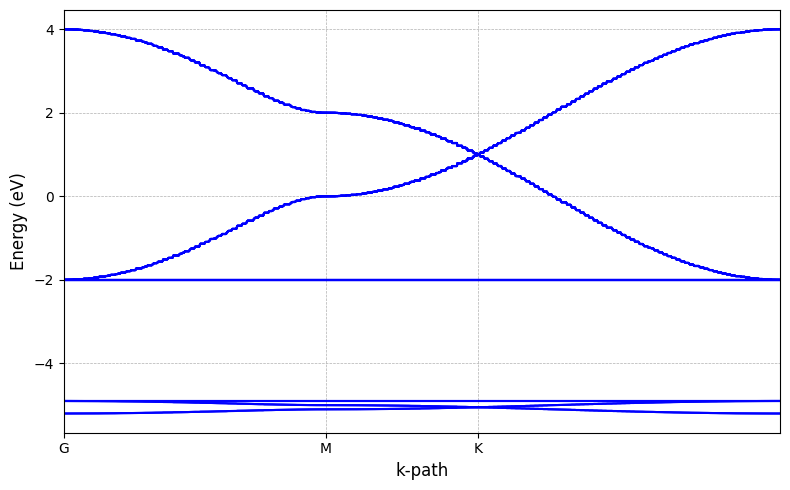

In [6]:
tb_bulk.plot_band_structure(g)

In [7]:
bands= [0, 1, 2, 3, 4, 5, 6, 7]
wf = problem.hamiltonian["bulk"]["topological_invariants"]
Z_2 = wf.Z2_invariant(bands=bands, print_deltas=True)
print("")
print(f"Z2 = {Z_2}")

Calculating Z2 Invariant...
k=[0. 0.]: delta = -1.0
k=[ 1.57079633 -0.90689968]: delta = 1.0
k=[0.         1.81379936]: delta = -1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!

Z2 = 0
